In [2]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [3]:
# experiments
avx512_run = pd.read_csv("./results/avx512_run.csv")
bitmap_run = pd.read_csv("./results/bitmap_run.csv")
bitmap_parallel_run = pd.read_csv("./results/bitmap_parallel_run.csv")
# taco
taco_sparse_run = pd.read_csv("./results/taco_csr_seq_run.csv")
taco_sparse_opt_run = pd.read_csv("./results/taco_csr_opt_run.csv")
taco_dense_run = pd.read_csv("./results/taco_dense_run.csv")
taco_dense_parallel_run = pd.read_csv("./results/taco_dense_parallel_run.csv")
# finch
finch_run = pd.read_csv("./results/finch_run.csv")
# torch
torch_sparse_run = pd.read_csv("./results/torch_run.csv")
torch_dense_run = pd.read_csv("./results/torch_dense_run.csv")
# mkl
mkl_sparse_run = pd.read_csv("./results/mkl_sparse_run.csv")


In [4]:
def format_runtime(df, name: str):
    df["kernel"] = name
    df['sparsity'] = df['A'].str.split('_').str[-1].str.split('.').str[0].astype(int)
    df['sparsity'] = 100 - df['sparsity']
    df.loc[df['kernel'] == 'finch_run', 'time'] = df.loc[df['kernel'] == 'finch_run', 'time'] * 1000
    df['seconds'] = df['time'] / 1000
    return df

In [5]:
data_frames = [
    # experiments
    format_runtime(avx512_run, "vectorized"),
    format_runtime(bitmap_run, "bitmap"),
    format_runtime(bitmap_parallel_run, "bitmap_parallel"),
    # taco
    format_runtime(taco_sparse_run, "taco_sparse"),
    format_runtime(taco_sparse_opt_run, "human_expert"),
    format_runtime(taco_dense_run, "taco_dense"),
    format_runtime(taco_dense_parallel_run, "taco_dense_parallel"),
    # finch
    format_runtime(finch_run, "finch"),
    # torch
    format_runtime(torch_dense_run, "torch_dense"),
    format_runtime(torch_sparse_run, "torch_sparse"),
    # mkl
    format_runtime(mkl_sparse_run, "mkl_sparse"),
]

In [6]:
full_df = pd.concat(data_frames)
full_df = full_df.sort_values(by=['M', 'sparsity'])
full_df = full_df.groupby(['kernel', 'sparsity', 'M'], as_index=False)['seconds'].mean()
full_df = full_df[full_df["M"] == 4096]

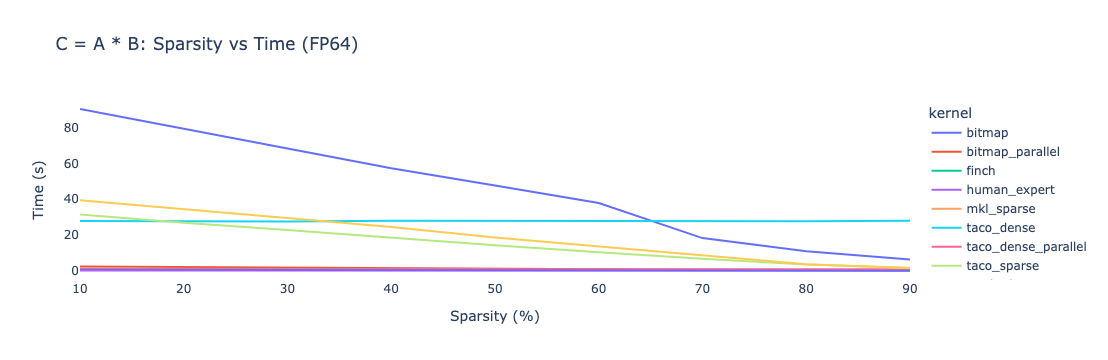

In [7]:
fig = px.line(full_df, 
              x='sparsity', 
              y='seconds', 
              color='kernel',
              title='C = A * B: Sparsity vs Time (FP64)',
              labels={'sparsity': 'Sparsity (%)', 'seconds': 'Time (s)'})
fig.update_layout(plot_bgcolor='white')
fig.show()